<img src="logoucm.png" style="height: 250px">
<center style="color:#888"><br/></center>




<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Ana Marta Oliveira dos Santos, Mario Queipo Silva y Siria Catherine Iniguez Brito***</span></center></font>

## Importamos las librerías necesarias

In [17]:
import numpy as np
import pandas as pd
from math import sin, cos, sqrt, log, exp, pi
import matplotlib.pyplot as plt
import scipy as sp
from numba import njit
from scipy.stats import t as t_student
from scipy.stats import norm
import seaborn as sns
import scipy.stats as si

<font size="6"><center><span style="color:blue">***Práctica 1: Generadores de números pseudoaleatorios***</span></center></font>

## 1. Método congruencial


Considerad los siguientes valores para los parámetros en el método congruencial:  
* m=2**(31)-1
* a=16807
* b=0  

y la semilla inicial en todos los casos será:  
* x0=123456789

In [18]:
m=2**(31)-1
a=16807
b=0
x0=123456789

In [19]:
@njit
def generador_congruencial_rapido(n, m, a, c, x0):
    u = np.zeros(n)
    x = x0
    for i in range(n):
        x = (a * x + c) % m
        u[i] = x / m
    return u, x

1. Para comprobar que está correctamente programado, generar 100 valores U(0,1). Éstos deben cumplir:  

    * $\overline{x} = 0.47682692$
    * $S^2_n = 0.09155876$
    * $S^2_{n-1} = 0.09248360$
    * $u1 = 0.2184183 ~ u2 = 0.95631758 ~ u3 = 0.82950923 . . .$  
    

2. Justificar que los números generados proceden de una distribución U(0,1).

## 2. Box-Müller


In [20]:
@njit
def generador_box_muller_rapido(n_pares, m, a, c, x0):
    u_total, x_final = generador_congruencial_rapido(2 * n_pares, m, a, c, x0)
    u1 = u_total[0::2]
    u2 = u_total[1::2]
    x = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    y = np.sqrt(-2.0 * np.log(u1)) * np.sin(2.0 * np.pi * u2)
    return x, y, x_final


1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.02737136$
    * $S^2_n = 1.079609$
    * $S^2_{n-1} = 1.090514$
    * $u1 = 1.679040257 ~ u2 = −0.566059812 ~ u3 = 1.212934217 . . .$
    * $\overline{y} = −0.1220177$
    * $S^2_n = 1.040119$
    * $S^2_{n-1} = 1.050626$
    * $u1 = −0.47276880 ~ u2 = −0.23112413 ~ u3 = 0.53503714 . . .$  
    

2. Justificar que los números generados proceden de una distribución N(0,1).

## 3. Método Marsaglia


1. Para comprobar que está correctamente programado, generar 100 valores N(0,1). Éstos deben cumplir:

    * $\overline{x} = 0.2159052$
    * $S^2_n = 0.7075141$
    * $S^2_{n-1} = 0.7146607$
    * $u1 = 1.24295692 ~ u2 = −0.13445768 ~ u3 = −0.30786186 . . .$
    * $\overline{y} = −0.1732801$
    * $S^2_n = 0.9229105$
    * $S^2_{n-1} = 0.9322328$
    * $u1 = 0.23272421 ~ u2 = −0.68882581 ~ u3 = −0.49533179 . . .$
    
    
2. Justificar que los números generados proceden de una distribución N(0,1).


## 2. Box-Müller antitéticas

## 2. Marsaglia antitéticas

## 4. t-Student


Para comprobar que está correctamente programado, generar 100 valores de la variable aleatoria $t_{10}$.
Éstos deben cumplir:
* $\overline{x} = −0.00024283$
* $S^2_n = 1.515859$
* $S^2_{n-1} = 1.531171$
* $u1 = −0.442199721 ~ u2 = 0.558411054 ~ u3 = 0.006160887 . . .$


<font size="6"><center><span style="color:blue">***Práctica 2***</span></center></font>

1. Generar un movimiento browniano unidimensional para T=100 con ∆𝑡=1 según la expresión:

<font size="3"><center>$X \leftarrow X + \sqrt{\Delta t } Z$ donde $Z \sim \mathcal{N}(0,1)$</center></font>

2. Generar 4 movimientos brownianos usando los valores de la distribución Normal generados mediante el seno y coseno del método de Box-Müller y también con variables antitéticas.

3. Generar 4 movimientos brownianos usando los valores de la ditribución normal generados mediante el método de Marsaglia y también con variables antitéticas.

<font size="2">*Nota: Reiniciar la semilla cada vez que se use un método nuevo.
Representar gráficamente las ocho trayectorias obtenidas. Verificar con estas imágenes:*</font>

<div class="pull-left"><img src="4movBM.png" style="height: 300px"></div>
<img src="4movMG.png" style="height: 300px">

4. Representar graficamente 1 movimiento browniano bidimensional.

<font size="7"><center><span style="color:blue">***Práctica 3***</span></center></font>

<font size="6"><center><span style="color:blue">***Práctica 3.1***</span></center></font>

<font size="4" color=blue>**Apartado a**</font>
***

Obtener los valores de una opción call y una opción put europeas con vencimiento $T$. Dar la estimación del valor y la precisión si:  

$$
V_{\mathrm{call}} = e^{-r_c t} \mathbb{E}_{\mathrm{riesgo~neutro}} [\textrm{payoff}] = (1+r)^{-t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}].
$$

- **(a.1.)** Obtener el valor de una opción call usando la fórmula de Black-Scholes:  

$$
V_{\mathrm{call}}(S,t) = Se^{-d_c t} \Phi(d_1) - Ke^{-r_c t} \Phi(d_2),
$$

donde:
$$
d_1 = \frac{\ln(S/K) + (r_c -d_c + 0.5 \sigma^2)t}{\sigma \sqrt{t}}, \quad d_2 = d_1 -\sigma\sqrt{t}.
$$

**Datos:**
- $r = 0.03$
- Strike = $14$
- Plazo $T = 1,2,3$
- $\sigma = 0.3$
- $S_0 = 14$
- $d = 0$

<font size="2">**Nota:** La varianza de la estimación del valor es $S^2_{\mathrm{call}} = (e^{-r_c t})^2 S^2_{\mathrm{\overline{payoff}}}$.
    
<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.856787;V_{\mathrm{put}}=1.449020$.</font>



In [21]:
# APARTADO a.1

# Datos
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
d_cont = 0.0  # d = 0
tiempos = [1, 2, 3]

# 1. Calcular la tasa continua rc a partir de la discreta r según: e^(-rc * t) = (1 + r)^-t
rc = np.log(1 + r_discreta)

def calcular_black_scholes(S, K, T, r, sigma, d):
    """Calcula el valor de una Call y Put europea usando Black-Scholes."""
    # Cálculo de d1 y d2 según las fórmulas
    d1 = (np.log(S / K) + (r - d + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Valor de la Call
    call = S * np.exp(-d * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    # Valor de la Put (usando Paridad Put-Call)
    # Put = Call - S*e^(-dt) + K*e^(-rt)
    put = call - S * np.exp(-d * T) + K * np.exp(-r * T)

    return call, put

# Ejecución y visualización de resultados
print("=" * 55)
print(" APARTADO a.1: VALORACIÓN MEDIANTE BLACK-SCHOLES ")
print("=" * 55)
print(f"{'T (Años)':<10} | {'V_call (Est.)':<15} | {'V_put (Est.)':<15}")
print("-" * 45)

for t in tiempos:
    v_call, v_put = calcular_black_scholes(S0, K, t, rc, sigma, d_cont)
    print(f"{t:<10} | {v_call:<15.6f} | {v_put:<15.6f}")

 APARTADO a.1: VALORACIÓN MEDIANTE BLACK-SCHOLES 
T (Años)   | V_call (Est.)   | V_put (Est.)   
---------------------------------------------
1          | 1.856787        | 1.449020       
2          | 2.708070        | 1.904413       
3          | 3.381072        | 2.193055       


<font size="4" color=blue>**Apartado b**</font>
***
Obtener los valores de una opción call y una opción put europeas con vencimiento $T = 1, 2, 3$ (con los mismos datos del apartado anterior). Dar la estimación del valor y la precisión si:  

$$
V_{\mathrm{call}} = e^{-r_c t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}] = (1+r)^{-t} \mathbb{E}_{\mathrm{riesgo~neutro}}[\textrm{payoff}].
$$

- **(b.1.)** Obtener el valor final del subyacente mediante la expresión en el plazo final:  

$$
S(t) = S(0) e^{(r_c - d_c - 0.5\sigma^2)t + \sigma \sqrt{t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.919841;Varianza=10.065818;Precisión=0.196879$.</font>
    
- **(b.2.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y la expresión (Lema de Itô):  

$$
S \leftarrow S e^{(r_c - d_c - 0.5\sigma^2)\Delta t + \sigma \sqrt{\Delta t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.008849;Varianza=10.349455;Precisión=0.199633$.</font>
    
- **(b.3.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y el mecanismo de transición. (Ecuación estocástica)  

$$
S \leftarrow S + S(r_{\Delta t} - d_{\Delta t})+\sigma S \sqrt{\Delta t}\mathcal{N}(0,1) = S(1+r-d)^{\Delta t} + \sigma S \sqrt{\Delta t} \mathcal{N}(0,1)
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.005745;Varianza=10.020386;Precisión=0.196434$.</font>
    
- **(b.4.)** Usando el valor final del subyacente mediante la expresión en el plazo final, determinar el tamaño muestral para que la estimación sea de un céntimo de Euro.


#Resolución:

- **(b.1.)** Obtener el valor final del subyacente mediante la expresión en el plazo final:  

$$
S(t) = S(0) e^{(r_c - d_c - 0.5\sigma^2)t + \sigma \sqrt{t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=1.919841;Varianza=10.065818;Precisión=0.196879$.</font>

In [22]:
# APARTADO b.1

# Datos
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
tiempos = [1, 2, 3]
n_sim = 1000

# Parámetros para el generador aleatorio
m=2**(31)-1
a=16807
c=0
x0=123456789

# Conversión a tasa continua
rc = np.log(1 + r_discreta)

print("=" * 100)
print(" "*25, "APARTADO b.1: SIMULACIÓN DEL VALOR FINAL DEL SUBYACENTE")
print("=" * 100)
print(f"{'T':<4} | {'V_call':<10} | {'S2_payoff_call':<12} | {'Precisión Call':<10} |  {'V_put':<10} | {'S2_payoff_put':<12} | {'Precisión Put':<10}")
print("-" * 100)

for t in tiempos:
    x0=123456789

    # Generar N(0,1) usando Box-Müller
    z1, z2, _ = generador_box_muller_rapido(n_sim, m, a, c, x0)
    Z = z2

    # Evolución del subyacente
    ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * Z)

    # Payoffs
    payoffs_call = np.maximum(ST - K, 0)
    payoffs_put = np.maximum(K - ST, 0)

    # Estimación del valor
    v_call = np.exp(-rc * t) * np.mean(payoffs_call)
    v_put = np.exp(-rc * t) * np.mean(payoffs_put)

    # Varianza de los payoffs (S2_payoff)
    s2_payoff_call = np.var(payoffs_call, ddof=1)
    s2_payoff_put = np.var(payoffs_put, ddof=1)

    # Varianza del estimador
    s2_estimador_call = np.exp(-2 * rc * t) * (s2_payoff_call)
    s2_estimador_put  = np.exp(-2 * rc * t) * (s2_payoff_put)

    # Precisión
    # t_critico para 95% confianza con n-1 grados de libertad
    t_crit = t_student.ppf(0.975, n_sim - 1)
    precision_call = t_crit * np.exp(-rc * t) * np.sqrt(s2_payoff_call/1000)
    precision_put = t_crit * np.exp(-rc * t) * np.sqrt(s2_payoff_put/1000)

    print(f"{t:<4} | {v_call:<10.6f} |   {s2_estimador_call:<12.6f} |    {precision_call:<10.6f}  |  {v_put:<10.6f} | {s2_estimador_put:<12.6f}  | {precision_put:<10.6f}")

                          APARTADO b.1: SIMULACIÓN DEL VALOR FINAL DEL SUBYACENTE
T    | V_call     | S2_payoff_call | Precisión Call |  V_put      | S2_payoff_put | Precisión Put
----------------------------------------------------------------------------------------------------
1    | 1.919841   |   10.065818    |    0.196879    |  1.414743   | 3.615416      | 0.117992  
2    | 2.807325   |   24.204675    |    0.305298    |  1.859360   | 5.830417      | 0.149839  
3    | 3.513282   |   41.678946    |    0.400620    |  2.141178   | 7.348510      | 0.168219  


    
- **(b.2.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y la expresión (Lema de Itô):  

$$
S \leftarrow S e^{(r_c - d_c - 0.5\sigma^2)\Delta t + \sigma \sqrt{\Delta t}\mathcal{N}(0,1)}.
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.008849;Varianza=10.349455;Precisión=0.199633$.</font>

In [23]:
# APARTADO b.2

# Datos
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
tiempos = [1, 2, 3]
n_sim = 1000
dt = 1/12  # Incremento de tiempo mensual

# Parámetros para el generador aleatorio
m = 2**31 - 1
a = 16807
c = 0

# Simulación
rc = np.log(1 + r_discreta)

print("=" * 85)
print(" "*15, " APARTADO b.2: VALORACIÓN POR SIMULACIÓN DE DINÁMICA 1 ")
print("=" * 85)
print(f"{'T':<4} | {'V_call':<10} | {'Varianza_C':<10} | {'Precisión_C':<10} | {'V_put':<10} | {'Varianza_P':<10} | {'Precisión_P':<10} |")
print("-" * 85)

for t in tiempos:
    seed_dinamica = 123456789 # Reinicio de semilla para cada T
    payoffs_call = []
    payoffs_put = []
    n_pasos = int(t * 12)

    for _ in range(n_sim):
        S = S0
        for _ in range(n_pasos):
            # Llamada directa a la función para 1 par de normales
            _, y, seed_dinamica = generador_box_muller_rapido(1, m, a, c, seed_dinamica)
            Z = y[0]

            # Evolución según Lema de Itô
            S = S * np.exp((rc - dc - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

        payoffs_call.append(np.maximum(S - K, 0))
        payoffs_put.append(np.maximum(K - S, 0))

    # Cálculos estadísticos
    v_call = np.exp(-rc * t) * np.mean(payoffs_call)
    v_put = np.exp(-rc * t) * np.mean(payoffs_put)
    s2_payoff_call = np.var(payoffs_call, ddof=1)
    s2_payoff_put = np.var(payoffs_put, ddof=1)

    # Varianza del estimador descontada
    varianza_estim_call = np.exp(-2 * rc * t) * s2_payoff_call
    varianza_estim_put = np.exp(-2 * rc * t) * s2_payoff_put

    t_crit = t_student.ppf(0.975, n_sim - 1)
    precision_call = t_crit * np.sqrt(varianza_estim_call / n_sim)
    precision_put = t_crit * np.sqrt(varianza_estim_put / n_sim)

    print(f"{t:<4} | {v_call:<10.6f} | {varianza_estim_call:<10.6f} | {precision_call:<10.6f}  | {v_put:<10.6f} | {varianza_estim_put:<10.6f} | {precision_put:<10.6f}  |")

                 APARTADO b.2: VALORACIÓN POR SIMULACIÓN DE DINÁMICA 1 
T    | V_call     | Varianza_C | Precisión_C | V_put      | Varianza_P | Precisión_P |
-------------------------------------------------------------------------------------
1    | 2.008849   | 10.349455  | 0.199633    | 1.388021   | 3.521192   | 0.116445    |
2    | 2.820939   | 26.995577  | 0.322419    | 1.852251   | 5.730004   | 0.148543    |
3    | 3.512672   | 47.959233  | 0.429745    | 2.163048   | 7.577450   | 0.170819    |


- **(b.3.)** Obtener el valor final del subyacente mediante simulación dinámica con $\Delta t = 1/12$ y el mecanismo de transición. (Ecuación estocástica)  

$$
S \leftarrow S + S(r_{\Delta t} - d_{\Delta t})+\sigma S \sqrt{\Delta t}\mathcal{N}(0,1) = S(1+r-d)^{\Delta t} + \sigma S \sqrt{\Delta t} \mathcal{N}(0,1)
$$

<font size="2" color=grey>**Nota para comprobación:** $t=1; V_{\mathrm{call}}=2.005745;Varianza=10.020386;Precisión=0.196434$.</font>

In [24]:
# APARTADO b.3

# Datos
S0 = 14.0
K = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
tiempos = [1, 2, 3]
n_sim = 1000
dt = 1/12  # Incremento de tiempo mensual

# Parámetros para el generador aleatorio
m = 2**31 - 1
a = 16807
c = 0

# Simulación
rc = np.log(1 + r_discreta)
print("=" * 85)
print("  APARTADO b.3: VALORACIÓN MEDIANTE SIMULACIÓN DINÁMICA CON TRANSICIÓN ESTOCÁSTICA ")
print("=" * 85)
print(f"{'T':<4} | {'V_call':<10} | {'Varianza_C':<10} | {'Precisión_C':<10} | {'V_put':<10} | {'Varianza_P':<10} | {'Precisión_P':<10} ")
print("-" * 85)

for t in tiempos:
    seed_dinamica = x0
    payoffs_call = []
    payoffs_put = []
    n_pasos = int(t * 12)

    for _ in range(n_sim):
        S = S0
        for _ in range(n_pasos):
            _, y, seed_dinamica = generador_box_muller_rapido(1, m, a, c, seed_dinamica)
            Z = y[0]

            # Apartado b.3
            # S = S * (1 + r - d)**dt + sigma * S * sqrt(dt) * Z
            S = S * (1 + r_discreta - dc)**dt + sigma * S * np.sqrt(dt) * Z

        payoffs_call.append(np.maximum(S - K, 0))
        payoffs_put.append(np.maximum(K - S, 0))

    # Cálculos estadísticos
    v_call = np.exp(-rc * t) * np.mean(payoffs_call)
    v_put = np.exp(-rc * t) * np.mean(payoffs_put)
    s2_payoff_call = np.var(payoffs_call, ddof=1)
    s2_payoff_put = np.var(payoffs_put, ddof=1)

    varianza_estim_call = np.exp(-2 * rc * t) * s2_payoff_call
    varianza_estim_put = np.exp(-2 * rc * t) * s2_payoff_put
    t_crit = t_student.ppf(0.975, n_sim - 1)
    precision_call = t_crit * np.sqrt(varianza_estim_call / n_sim)
    precision_put = t_crit * np.sqrt(varianza_estim_put / n_sim)

    print(f"{t:<4} | {v_call:<10.6f} | {varianza_estim_call:<10.6f} | {precision_call:<10.6f}  | {v_put:<10.6f} | {varianza_estim_put:<10.6f} | {precision_put:<10.6f} ")

  APARTADO b.3: VALORACIÓN MEDIANTE SIMULACIÓN DINÁMICA CON TRANSICIÓN ESTOCÁSTICA 
T    | V_call     | Varianza_C | Precisión_C | V_put      | Varianza_P | Precisión_P 
-------------------------------------------------------------------------------------
1    | 2.005745   | 10.020386  | 0.196434    | 1.392958   | 3.616090   | 0.118003   
2    | 2.821879   | 26.324605  | 0.318387    | 1.859360   | 5.803167   | 0.149488   
3    | 3.529372   | 46.426739  | 0.422823    | 2.178953   | 7.698520   | 0.172178   


- **(b.4.)** Usando el valor final del subyacente mediante la expresión en el plazo final, determinar el tamaño muestral para que la estimación sea de un céntimo de Euro.

In [25]:
@njit
def simular_plazo_normal(T, S0, K, rc, dc, sigma, threshold, z_crit, m, a, c, x0_original):
    var = 0.0
    suma_Y = 0.0
    xrand = x0_original
    precision = 2.0 * threshold
    # --- Primera iteración ---
    _, normales_y, xrand = generador_box_muller_rapido(1, m, a, c, xrand)
    Z = normales_y[0]

    payoff = max(S0 * np.exp((rc - dc - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z) - K, 0.0) * np.exp(-rc * T)
    suma_Y += payoff
    media_n = payoff

    n = 1

    while precision > threshold:
        n += 1

        _, normales_y, xrand = generador_box_muller_rapido(1, m, a, c, xrand)
        Z = normales_y[0]

        payoff = max(S0 * np.exp((rc - dc - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z) - K, 0.0) * np.exp(-rc * T)
        suma_Y += payoff

        # Actualización recursiva de la varianza
        var = 1.0 / (n - 1) * ((n - 2) * var + 1.0 / n / (n - 1) * (suma_Y - n * payoff)**2)

        # Actualización de la media móvil
        media_n = media_n + (payoff - media_n) / n

        if var > 0.0:
            # Multiplicamos por el valor crítico de la Normal (z_crit)
            precision = z_crit * np.sqrt(var / n)
        else:
            precision = 2.0 * threshold

    return media_n, var, n, precision


# Datos
S0, K = 14.0, 14.0
r_discreta = 0.03
sigma = 0.3
alpha = 0.05
threshold = 0.01

d_discreta = 0.0

rc = np.log(1 + r_discreta)
dc = np.log(1 + d_discreta) if d_discreta > 0.0 else 0.0

# Parámetros para el generador aleatorio
m = 2**31 - 1
a = 16807
c = 0
x0_original = 123456789

# Valor crítico Z para alpha = 0.05 (Confianza del 95%)
z_crit = 1.9599639845400542

print("=" * 72)
print(" APARTADO b.4: DETERMINACIÓN DEL TAMAÑO MUESTRAL SECUENCIAL CON ϵ = 0.01 ")
print("=" * 72)
print(f"{'T':<5} | {'V_call':<12} | {'Varianza':<12} | {'n Normal':<12} | {'Precisión'}")
print("-" * 72)

# Lanzamiento de la simulación ---
for T in [1, 2, 3]:
    media_n, var, n, precision = simular_plazo_normal(
        T, S0, K, rc, dc, sigma, threshold, z_crit, m, a, c, x0_original)

    print(f"{T:<5} | {media_n:<12.4f} | {var:<12.4f} | {n:<12} | {precision:.6f}")

 APARTADO b.4: DETERMINACIÓN DEL TAMAÑO MUESTRAL SECUENCIAL CON ϵ = 0.01 
T     | V_call       | Varianza     | n Normal     | Precisión
------------------------------------------------------------------------
1     | 1.8601       | 9.4060       | 361331       | 0.010000
2     | 2.7026       | 22.3156      | 857245       | 0.010000
3     | 3.3821       | 38.4407      | 1476684      | 0.010000


<font size="6"><center><span style="color:blue">***Práctica 3.2***</span></center></font>

- **(b.)** Obtener mediante simulación el valor de una estrategia **butterfly** formada por la compra de una opción call europea con strike $K$, la compra de otra opción europea con strike $K'>K$ y la venta de dos opciones call europeas con strike $K''$ tal que $K<K''<K'$, todas sobre el mismo subyacente.  
Aplicarlo suponiendo los datos de las prácticas anteriores con $K = 14, K' = 16$ y $K'' = 15$.

- **(a.)** Teniendo en cuenta las consideraciones anteriores y dependiendo del resultado del subyacente define y muestra la tabla de payoffs antes de desarrollar el código.  

- **(c.)** Grafica el resultado y comprueba que el gráfico tiene la misma forma que lo ya visto en la parte de teoría.

- **(d.)** Muestra graficamente cual sería el beneficio obtenido, es decir, considerando el coste de la prima.

- **(e.)** Los mismos apartados anteriores para una estrategia **strangle** (tipo cuna, forma parte de la especulativas) formada por la compra de una opción call europea con strike $K'$ y una opción put con strike $K$, con $K'>K$.

#Resolución:

- **(a.)** Teniendo en cuenta las consideraciones anteriores y dependiendo del resultado del subyacente define y muestra la tabla de payoffs antes de desarrollar el código.

| Escenario Subyacente | $\text{Call } K$ | $2 \times \text{Call } K''$ | $\text{Call } K'$ | Resultado General de la Estrategia |
| :---: | :---: | :---: | :---: | :---: |
| $S \le K$ | $0$ | $0$ | $0$ | $0$ |
| $K < S \le K''$ | $S - K$ | $0$ | $0$ | $S - K$ |
| $K'' < S \le K'$ | $S - K$ | $-2(S - K'')$ | $0$ | $2K'' - K - S$ |
| $S > K'$ | $S - K$ | $-2(S - K'')$ | $S - K'$ | $2K'' - K - K'$ |

- **(b.)** Obtener mediante simulación el valor de una estrategia **butterfly** formada por la compra de una opción call europea con strike $K$, la compra de otra opción europea con strike $K'>K$ y la venta de dos opciones call europeas con strike $K''$ tal que $K<K''<K'$, todas sobre el mismo subyacente.  
Aplicarlo suponiendo los datos de las prácticas anteriores con $K = 14, K' = 16$ y $K'' = 15$.

- **(c.)** Grafica el resultado y comprueba que el gráfico tiene la misma forma que lo ya visto en la parte de teoría.

La estrategia **Butterfly Spread**  es una estructura acotada que se construye mediante la combinación de tres tramos con diferentes precios de ejercicio sobre el mismo activo subyacente, cumpliendo la relación $K < K'' < K'$. En este caso particular, los parámetros son:

1. **Compra (Largo)** de 1 Call con precio de ejercicio bajo ($K = 14$).
2. **Venta (Corto)** de 2 Calls con precio de ejercicio medio ($K'' = 15$).
3. **Compra (Largo)** de 1 Call con precio de ejercicio alto ($K' = 16$).

A continuación, se detalla el comportamiento algebraico y el desglose del payoff resultante en cada uno de los rangos posibles en los que puede expirar el precio del subyacente ($S_T$) al vencimiento:

---

#### 1. Rango $S_T \le K$ *(Caso particular: $S_T \le 14$)*
* **Comportamiento:** El precio del activo no logra superar ni siquiera el strike más bajo. Todas las opciones de la estrategia expiran completamente *Out-of-the-Money* (OTM), por lo que ninguna se ejerce.
* **Desarrollo General:** $0 - 2(0) + 0 = 0$
* **Resultado Neto:** $\mathbf{0}$

#### 2. Rango $K < S_T \le K''$ *(Caso particular: $14 < S_T \le 15$)*
* **Comportamiento:** El subyacente supera el primer umbral. Únicamente la opción comprada con strike $K$ entra *In-the-Money* (ITM), acumulando un valor intrínseco de $(S_T - K)$. Las opciones vendidas ($K''$) y la opción comprada superior ($K'$) se mantienen en valor cero.
* **Desarrollo General:** $(S_T - K) - 2(0) + 0$
* **Resultado Neto:** $\mathbf{S_T - 14}$ *(El beneficio de la estrategia aumenta de forma lineal a partir de 14)*.

#### 3. Rango $K'' < S_T \le K'$ *(Caso particular: $15 < S_T \le 16$)*
* **Comportamiento:** El subyacente supera el strike central. La primera Call sigue en positivo $(S_T - K)$, pero ahora las 2 opciones vendidas entran en pérdidas para nosotros, restando $-2(S_T - K'')$. La opción con strike $K'$ sigue valiendo cero.
* **Desarrollo General:** $(S_T - K) - 2(S_T - K'') + 0 \;\rightarrow\; S_T - K - 2S_T + 2K''$
* **Simplificación:** $2K'' - K - S_T$
* **Sustitución Numérica:** $2(15) - 14 - S_T = \mathbf{16 - S_T}$ *(El beneficio neto empieza a disminuir linealmente desde su punto máximo)*.

#### 4. Rango $S_T > K'$ *(Caso particular: $S_T > 16$)*
* **Comportamiento:** En este extremo alcista, las tres opciones se encuentran profundamente *In-the-Money* (ITM) y se ejecutan en su totalidad.
* **Desarrollo General:** $(S_T - K) - 2(S_T - K'') + (S_T - K')$
* **Agrupación Algebraica:** $(S_T - 2S_T + S_T) + (2K'' - K - K') \;\rightarrow\; 0 + (2K'' - K - K')$
* **Constante del Extremo Derecho:** $2K'' - K - K'$
* **Sustitución Numérica:** $2(15) - 14 - 16 = 30 - 30 = \mathbf{0}$

---

En este caso particular, como los tres precios de ejercicio están a la misma distancia uno del otro ($15 - 14 = 1$ y $16 - 15 = 1$), la estrategia es simétrica. Esto hace que las ganancias y las pérdidas se cancelen por completo si la acción sube demasiado. Así, si el precio supera los $16$, el resultado final será siempre cero, sin importar cuánto más suba la acción.


S_T Simulado    | Payoff Butterfly
---------------------------------
11.9626         | 0.0000         
12.8620         | 0.0000         
16.1857         | 0.0000         
18.8871         | 0.0000         
7.8778          | 0.0000         
17.1905         | 0.0000         
9.1926          | 0.0000         
13.8177         | 0.0000         
15.4267         | 0.5733         
14.5748         | 0.5748         


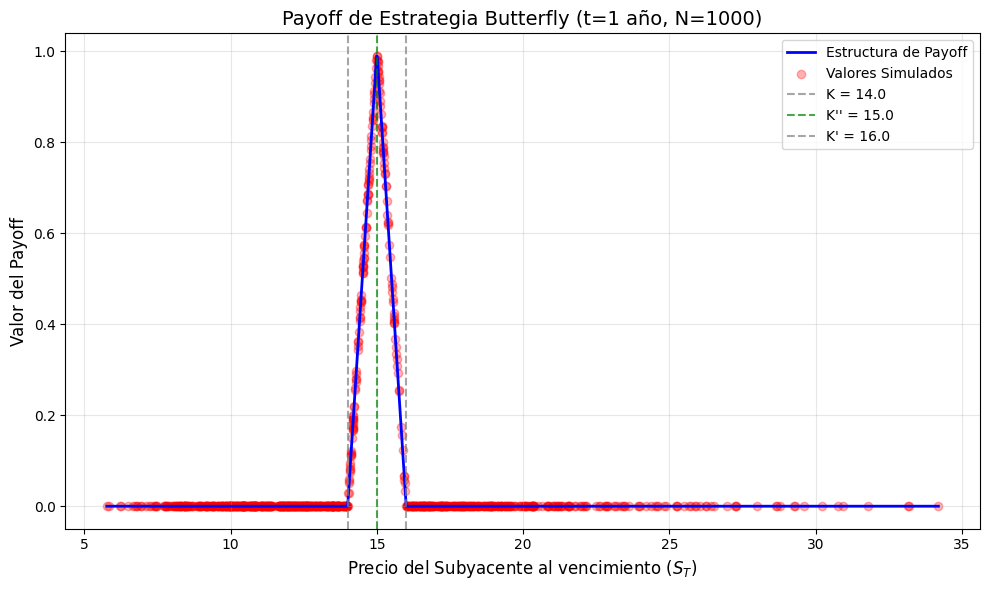

In [26]:
# Datos
S0 = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
t = 1  # Evaluamos en t=1
n_sim = 1000

# Strikes de la estrategia Butterfly
K = 14.0
K_prima = 16.0
K_biprima = 15.0

# Parámetros para el generador aleatorio
m = 2**31 - 1
a = 16807
c = 0
x0 = 123456789

# Conversión a tasa continua
rc = np.log(1 + r_discreta)

# Generación de simulaciones de S_T
z1, z2, _ = generador_box_muller_rapido(n_sim, m, a, c, x0)
Z = z2

# Evolución del subyacente
ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * Z)

# Evaluación y almacenamiento del Payoff de la Butterfly
call_K = np.maximum(ST - K, 0)
call_K_prima = np.maximum(ST - K_prima, 0)
call_K_biprima = np.maximum(ST - K_biprima, 0)

payoffs_butterfly = call_K + call_K_prima - 2 * call_K_biprima

# Mostramos los primeros valores
print(f"{'S_T Simulado':<15} | {'Payoff Butterfly':<15}")
print("-" * 33)
for i in range(10):
    print(f"{ST[i]:<15.4f} | {payoffs_butterfly[i]:<15.4f}")

# Gráfica de los resultados
ST_ordenado = np.sort(ST)
payoffs_teorico = (np.maximum(ST_ordenado - K, 0) +
                   np.maximum(ST_ordenado - K_prima, 0) -
                   2 * np.maximum(ST_ordenado - K_biprima, 0))

plt.figure(figsize=(10, 6))

# Dibujar la línea de la estructura de pagos
plt.plot(ST_ordenado, payoffs_teorico, color='blue', linewidth=2, label='Estructura de Payoff')

# Superponer los puntos exactos que el modelo ha simulado
plt.scatter(ST, payoffs_butterfly, color='red', alpha=0.3, label='Valores Simulados')

# Marcar los strikes con líneas verticales
plt.axvline(x=K, color='gray', linestyle='--', alpha=0.7, label=f"K = {K}")
plt.axvline(x=K_biprima, color='green', linestyle='--', alpha=0.7, label=f"K'' = {K_biprima}")
plt.axvline(x=K_prima, color='gray', linestyle='--', alpha=0.7, label=f"K' = {K_prima}")

# Configuración visual
plt.title(f'Payoff de Estrategia Butterfly (t={t} año, N={n_sim})', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Valor del Payoff', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar gráfica
plt.show()

La gráfica permite contrastar el perfil de riesgo teórico de nuestra mariposa frente a los mil escenarios generados por el simulador. Del análisis de esta distribución se extraen lo siguientes:

* **Fidelidad en la Réplica Geométrica:** La simulación refleja la silueta de "tienda de campaña" propia del *Butterfly Spread*. Como se aprecia en la **línea azul**, el diseño de la estrategia bloquea el beneficio en cero tanto para caídas por debajo de $K=14.0$ como para subidas que superen el límite de $K'=16.0$. El rendimiento escala de manera limpia y lineal en los intervalos intermedios hasta tocar su techo de **1.00 €** en el eje central ($K''=15.0$).

* **Ausencia de Ruido y Comportamiento Determinista:** Un aspecto fundamental del gráfico es que los puntos rojos (los datos simulados) caen de forma milimétrica sobre la guía azul, sin mostrar dispersión hacia arriba o hacia abajo. Esto ilustra de manera práctica un pilar de las finanzas cuantitativas: al vencimiento, el beneficio de una opción no es aleatorio, sino una **función determinista** del precio del activo. La incertidumbre del modelo rige el camino que recorre la acción hasta llegar a $T$, pero una vez que el precio final se fija, el veredicto de la estrategia es único y exacto.

* **Anatomía de la Distribución Lognormal:** La acumulación de marcas rojas a lo largo de la base refleja de forma fidedigna la asimetría probabilística del activo bajo un movimiento geométrico browniano. Al simular a un horizonte de largo plazo ($t = 1$ año) con una volatilidad alta ($\sigma = 30\%$), la nube de puntos se desplaza y extiende de manera desigual: observamos una altísima concentración de escenarios aglomerados en la zona baja e intermedia izquierda (entre los $5.0$ € y los $14$ €), mientras que hacia el flanco derecho los puntos se van distanciando gradualmente, dibujando una cola extremadamente larga y delgada que llega a superar los $34.0$ €.

  Esta perspectiva visual ayuda a entender la verdadera naturaleza matemática del negocio: la inmensa mayoría de las trayectorias aleatorias simulan precios que expiran fuera de los límites de ejercicio. Al morir masivamente en las extensas llanuras laterales de beneficio cero, se evidencia que la probabilidad estadística de que la acción termine confinada estrictamente en el angosto rango del triángulo ($14.0 < S_T < 16.0$) es reducida.

- **(d.)** Muestra graficamente cual sería el beneficio obtenido, es decir, considerando el coste de la prima.

--- Desglose de Costes (t=0) ---
Call K (14.0):      1.8568
Call K' (16.0):     1.0976
Call K'' (15.0):    1.4359 (x2)
Prima Neta:       0.0826
Comisiones:       0.0291
COSTE TOTAL:      0.1117



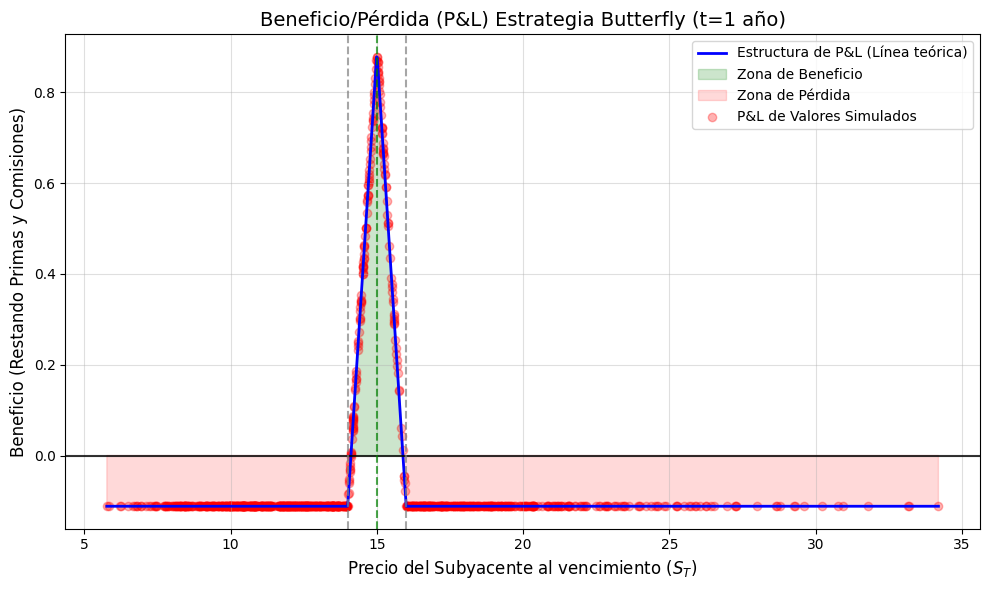

In [27]:
# Apartado d):

# Configuración de parámetros
S0 = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
t = 1
n_sim = 1000

K = 14.0
K_prima = 16.0
K_biprima = 15.0

# Conversión a tasa continua
rc = np.log(1 + r_discreta)

# Cálculo de Primas y Costes en t=0
C_K, _ = calcular_black_scholes(S0, K, t, rc, sigma, dc)
C_K_prima, _ = calcular_black_scholes(S0, K_prima, t, rc, sigma, dc)
C_K_biprima, _ = calcular_black_scholes(S0, K_biprima, t, rc, sigma, dc)

# Prima neta (lo que pagas menos lo que ingresas)
prima_neta = C_K + C_K_prima - (2 * C_K_biprima)

# Comisiones (0.5% sobre el volumen total de primas operadas)
comisiones = 0.005 * (C_K + C_K_prima + (2 * C_K_biprima))

# Coste total de armar la estrategia
coste_total = prima_neta + comisiones

print("--- Desglose de Costes (t=0) ---")
print(f"Call K ({K}):      {C_K:.4f}")
print(f"Call K' ({K_prima}):     {C_K_prima:.4f}")
print(f"Call K'' ({K_biprima}):    {C_K_biprima:.4f} (x2)")
print(f"Prima Neta:       {prima_neta:.4f}")
print(f"Comisiones:       {comisiones:.4f}")
print(f"COSTE TOTAL:      {coste_total:.4f}\n")

# Generación de simulaciones
m, a, c, x0 = 2**31 - 1, 16807, 0, 123456789
_, z2, _ = generador_box_muller_rapido(n_sim, m, a, c, x0)
ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * z2)

# Evaluación del Payoff y P&L (Beneficio/Pérdida)
call_K_sim = np.maximum(ST - K, 0)
call_K_prima_sim = np.maximum(ST - K_prima, 0)
call_K_biprima_sim = np.maximum(ST - K_biprima, 0)

payoffs_butterfly = call_K_sim + call_K_prima_sim - 2 * call_K_biprima_sim

# Restamos el coste total para obtener el Beneficio Real (Profit & Loss)
pnl_butterfly = payoffs_butterfly - coste_total

# Gráfica de P&L
ST_ordenado = np.sort(ST)
payoffs_teorico = (np.maximum(ST_ordenado - K, 0) +
                   np.maximum(ST_ordenado - K_prima, 0) -
                   2 * np.maximum(ST_ordenado - K_biprima, 0))
pnl_teorico = payoffs_teorico - coste_total

plt.figure(figsize=(10, 6))

# Línea teórica de Beneficio/Pérdida
plt.plot(ST_ordenado, pnl_teorico, color='blue', linewidth=2, label='Estructura de P&L (Línea teórica)')

# Sombreado verde para ganancias (valores por encima de 0)
plt.fill_between(ST_ordenado, pnl_teorico, 0, where=(pnl_teorico > 0), color='green', alpha=0.2, label='Zona de Beneficio')

# Sombreado rojo para pérdidas (valores por debajo de 0)
plt.fill_between(ST_ordenado, pnl_teorico, 0, where=(pnl_teorico < 0), color='red', alpha=0.15, label='Zona de Pérdida')

# Puntos simulados de Beneficio/Pérdida
plt.scatter(ST, pnl_butterfly, color='red', alpha=0.3, label='P&L de Valores Simulados')

# Línea cero (Breakeven point general)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

# Marcar strikes
plt.axvline(x=K, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=K_biprima, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=K_prima, color='gray', linestyle='--', alpha=0.7)

# Configuración visual
plt.title(f'Beneficio/Pérdida (P&L) Estrategia Butterfly (t={t} año)', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Beneficio (Restando Primas y Comisiones)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

Al incorporar el coste total de la estrategia (primas netas más comisiones de operación), el gráfico se transforma de un simple perfil de ingresos (*payoff*) a una verdadera estructura de **Beneficio/Pérdida Neto (P&L)**. Del análisis de esta nueva distribución visual, podemos extraer las siguientes conclusiones:

* **El Costo del "Boleto de Entrada":** A diferencia del gráfico de payoffs donde la base tocaba el cero, aquí toda la estructura se desplaza verticalmente hacia abajo. Ese sutil hundimiento representa el coste de armar la estrategia en $t=0$. Si el activo termina fuera del intervalo de los strikes, el inversor no se queda en cero, sino que asume una **pérdida máxima constante acotada** (marcada por la extensa **zona roja** de pérdidas), que corresponde exactamente al dinero invertido inicialmente.

* **Estrechamiento del Umbral de Ganancias:** El sombreado verde revela visualmente la "zona de vida" de la estrategia. Un detalle crucial es que los puntos de cruce con el eje cero ya no coinciden exactamente con los strikes laterales $K=14$ y $K'=16$, sino que se han desplazado ligeramente hacia el centro. Para ganar dinero, el precio del subyacente no solo tiene que quedar atrapado en el triángulo, sino que debe superar el coste total pagado por la estructura.

* **Mitigación del Riesgo y Techo de Rendimiento:** La **zona verde** ilustra la gran ventaja y, a la vez, la limitación del *Butterfly Spread*. El beneficio está estrictamente topado en $K''=15$, alcanzando un neto algo inferior a 1.00 € debido al impacto de los costes y las comisiones. Sin embargo, el gráfico demuestra que es una estrategia excelente para escenarios de baja volatilidad: el riesgo de pérdidas en las colas laterales está perfectamente plano y controlado, sin importar si la acción se desploma a 5.0 € o se dispara a 35.0 €.

# Ejercicio Extra: Análisis de Sensibilidad de la Butterfly — Black-Scholes Teórico

Se usa la fórmula analítica de Black-Scholes para estudiar cómo cambia el **valor teórico** de la estrategia Butterfly en función del **plazo T** y de la **volatilidad σ**, y se construyen mapas de calor de las griegas **Theta** y **Vega**.

Parámetros base: $S_0=14$, $K=14$, $K''=15$, $K'=16$, $r=0.03$, $d=0$.

### Apartado f) - Sensibilidad al tiempo




Tiempo (T)   | Prima Neta   | Comisiones   | Coste Total (Pérdida Máx)
----------------------------------------------------------------------
1            | 0.0826       | 0.0291       | 0.1117
0.5          | 0.1152       | 0.0179       | 0.1331
0.25         | 0.1551       | 0.0106       | 0.1657
0.1          | 0.2099       | 0.0050       | 0.2149


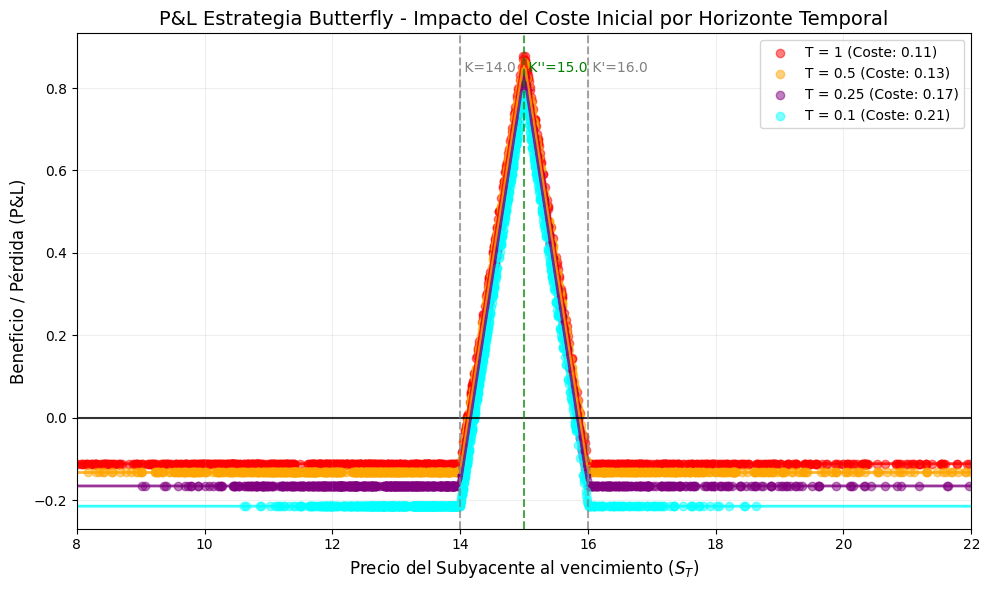

In [28]:
# Configuración de parámetros
S0 = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
n_sim = 1000

K = 14.0
K_prima = 16.0
K_biprima = 15.0

tiempos = [1, 0.5, 0.25, 0.1]
colores = ['red', 'orange', 'purple', 'cyan']

rc = np.log(1 + r_discreta)
m, a, c = 2**31 - 1, 16807, 0

plt.figure(figsize=(10, 6))

# Rango para dibujar las líneas teóricas continuas
ST_rango = np.linspace(5, 25, 500)

print(f"{'Tiempo (T)':<12} | {'Prima Neta':<12} | {'Comisiones':<12} | {'Coste Total (Pérdida Máx)'}")
print("-" * 70)

# Bucle principal para cada horizonte temporal
for t, color in zip(tiempos, colores):
    # --- A. Valoración inicial (t=0) ---
    C_K, _ = calcular_black_scholes(S0, K, t, rc, sigma, dc)
    C_K_prima, _ = calcular_black_scholes(S0, K_prima, t, rc, sigma, dc)
    C_K_biprima, _ = calcular_black_scholes(S0, K_biprima, t, rc, sigma, dc)

    prima_neta = C_K + C_K_prima - (2 * C_K_biprima)
    comisiones = 0.005 * (C_K + C_K_prima + (2 * C_K_biprima))
    coste_total = prima_neta + comisiones

    print(f"{t:<12} | {prima_neta:<12.4f} | {comisiones:<12.4f} | {coste_total:.4f}")

    # --- B. Simulación al vencimiento (t=T) ---
    x0_seed = 123456789
    _, z2, _= generador_box_muller_rapido(n_sim, m, a, c, x0_seed)
    ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * z2)

    # --- C. Cálculo de P&L de las simulaciones ---
    call_K_sim = np.maximum(ST - K, 0)
    call_K_prima_sim = np.maximum(ST - K_prima, 0)
    call_K_biprima_sim = np.maximum(ST - K_biprima, 0)

    payoffs_butterfly = call_K_sim + call_K_prima_sim - 2 * call_K_biprima_sim
    pnl_butterfly = payoffs_butterfly - coste_total  # Restamos el coste específico de este T

    # --- D. Cálculo de la línea teórica para este T ---
    payoffs_teorico = (np.maximum(ST_rango - K, 0) +
                       np.maximum(ST_rango - K_prima, 0) -
                       2 * np.maximum(ST_rango - K_biprima, 0))
    pnl_teorico = payoffs_teorico - coste_total

    # --- E. Graficado ---
    # Dibujamos la línea teórica de este T
    plt.plot(ST_rango, pnl_teorico, color=color, linewidth=2, alpha=0.8)

    # Superponemos los puntos simulados
    plt.scatter(ST, pnl_butterfly, color=color, alpha=0.5, label=f'T = {t} (Coste: {coste_total:.2f})')

# 4. Configuración visual final
# Línea cero (Breakeven point general)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

# Marcar strikes
plt.axvline(x=K, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=K_biprima, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=K_prima, color='gray', linestyle='--', alpha=0.7)

# Textos para los strikes
plt.text(K, plt.ylim()[1]*0.90, f' K={K}', color='gray')
plt.text(K_biprima, plt.ylim()[1]*0.90, f' K\'\'={K_biprima}', color='green')
plt.text(K_prima, plt.ylim()[1]*0.90, f' K\'={K_prima}', color='gray')

plt.xlim(8, 22)

plt.title('P&L Estrategia Butterfly - Impacto del Coste Inicial por Horizonte Temporal', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Beneficio / Pérdida (P&L)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

### Sensibilidad de la Estrategia al Horizonte Temporal
El análisis conjunto de la tabla y los resultados simulados revela una dinámica fundamental del comportamiento de las opciones: **el impacto del paso del tiempo (*Theta*) sobre el valor de la estructura**. A partir de los datos obtenidos, se extraen los siguientes hallazgos clave:

* **Evolución del Coste Inicial y Pérdida Máxima:** A medida que el horizonte temporal se reduce ($T = 1 \rightarrow T = 0.1$), la prima neta de la estrategia **se incrementa de 0.0826 € a 0.2099 €**. Como consecuencia, el coste total de instalación asciende, elevando la pérdida máxima potencial ante escenarios donde el activo expire fuera de los strikes.
* **Efecto Visual en el Perfil de P&L:** Gráficamente, este fenómeno provoca un **desplazamiento vertical hacia abajo** de toda la estructura a medida que $T$ decrece. La curva cian ($T=0.1$) exhibe el suelo de pérdidas más profundo y, por ende, el pico de beneficio neto más bajo de todo el estudio.
* **Comportamiento de la Dispersión:** Adicionalmente, el gráfico ilustra cómo el horizonte temporal comprime la campana de resultados: para plazos cortos ($T=0.1$), los puntos simulados se aglutinan estrechamente alrededor del precio inicial ($S_0=14$), mientras que para plazos largos ($T=1$), la dispersión se ensancha debido a que el subyacente dispone de más tiempo para realizar movimientos volátiles.

### Apartado g) - Sensibilidad a la volatilidad



Sigma        | Prima Neta   | Comisiones   | Coste Total
-----------------------------------------------------------------
0.1          | 0.2642       | 0.0039       | 0.2681
0.2          | 0.1654       | 0.0104       | 0.1758
0.3          | 0.1152       | 0.0179       | 0.1331
0.4          | 0.0875       | 0.0256       | 0.1131


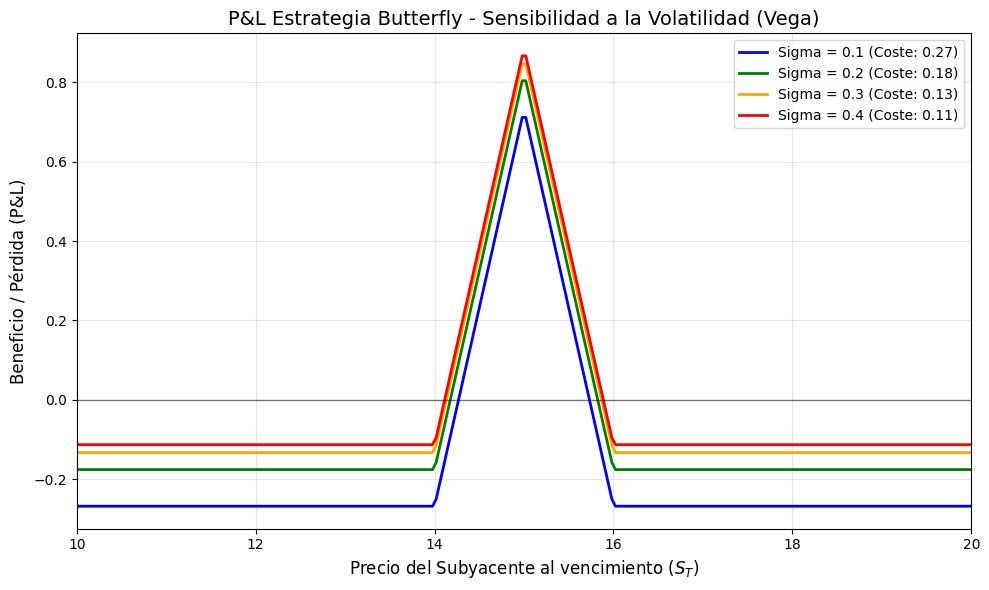

In [29]:
# Configuración de parámetros constantes
S0 = 14.0
r_discreta = 0.03
T_fijo = 0.5  # Mantenemos T constante para analizar Vega
dc = 0.0
n_sim = 1000

K = 14.0
K_prima = 16.0
K_biprima = 15.0

# Lista de volatilidades
sigmas = [0.1, 0.2, 0.3, 0.4]
colores_sigma = ['blue', 'green', 'orange', 'red']

rc = np.log(1 + r_discreta)

plt.figure(figsize=(10, 6))
ST_rango = np.linspace(5, 25, 500)

print(f"{'Sigma':<12} | {'Prima Neta':<12} | {'Comisiones':<12} | {'Coste Total'}")
print("-" * 65)

# Bucle principal para cada nivel de volatilidad
for sigma, color in zip(sigmas, colores_sigma):
    # --- A. Valoración inicial (coste de la estrategia) ---
    C_K, _ = calcular_black_scholes(S0, K, T_fijo, rc, sigma, dc)
    C_K_prima, _ = calcular_black_scholes(S0, K_prima, T_fijo, rc, sigma, dc)
    C_K_biprima, _ = calcular_black_scholes(S0, K_biprima, T_fijo, rc, sigma, dc)

    prima_neta = C_K + C_K_prima - (2 * C_K_biprima)
    comisiones = 0.005 * (C_K + C_K_prima + (2 * C_K_biprima))
    coste_total = prima_neta + comisiones

    print(f"{sigma:<12} | {prima_neta:<12.4f} | {comisiones:<12.4f} | {coste_total:.4f}")

    # --- B. Cálculo de P&L teórico ---

    payoffs_teorico = (np.maximum(ST_rango - K, 0) +
                       np.maximum(ST_rango - K_prima, 0) -
                       2 * np.maximum(ST_rango - K_biprima, 0))
    pnl_teorico = payoffs_teorico - coste_total

    # --- C. Graficado ---
    plt.plot(ST_rango, pnl_teorico, color=color, linewidth=2,
             label=f'Sigma = {sigma} (Coste: {coste_total:.2f})')

# Configuración visual final
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlim(10, 20)
plt.title('P&L Estrategia Butterfly - Sensibilidad a la Volatilidad (Vega)', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Beneficio / Pérdida (P&L)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Sensibilidad de la Estrategia a la Volatilidad (Impacto de Vega)

El análisis numérico y gráfico revela **el impacto inverso de la volatilidad ($\sigma$) sobre el coste de las estrategias de rango o "compras de volatilidad negativa"**. A partir de los resultados obtenidos, se extraen las siguientes conclusiones principales:

* **Relación Inversa entre Volatilidad y Coste:** Contrario a lo que ocurre con una opción Call o Put individual (donde a mayor volatilidad, mayor es la prima), en la estrategia Butterfly **un incremento de la volatilidad reduce drásticamente el coste total**. Al pasar de una $\sigma = 0.1$ a $\sigma = 0.4$, el coste total de instalación cae de **0.2681 € a 0.1131 €**. Esto se debe a que un entorno de alta volatilidad eleva el valor de las dos opciones que vendemos en el centro ($K''=15.0$) a un ritmo mucho más rápido del que aumentan las opciones que compramos en los extremos, abaratando la estructura neta.
* **Desplazamiento Vertical Positivo del P&L:** Visualmente, este abaratamiento se traduce en un **desplazamiento vertical hacia arriba** de todo el perfil de Beneficio/Pérdida neto. La curva roja ($\sigma = 0.4$) presenta la pérdida máxima más pequeña (la llanura lateral está más cerca de cero) y, por consiguiente, logra el pico de beneficio neto más alto del gráfico al restar un menor coste inicial al payoff bruto.
* **La Paradoja de Vega en la Mariposa:** Aunque comprar la mariposa con volatilidad alta ofrece un perfil de P&L numéricamente más atractivo, esto es matemáticamente compensatorio. Una volatilidad del $40\%$ implica que la probabilidad real de que el subyacente termine confinado dentro del estrecho rango de ganancias ($14 < S_T < 16$) es drásticamente menor en comparación con un escenario de volatilidad del $10\%$. La estructura es más barata porque la probabilidad de éxito disminuye.

### Apartado h) - Mapa de calor

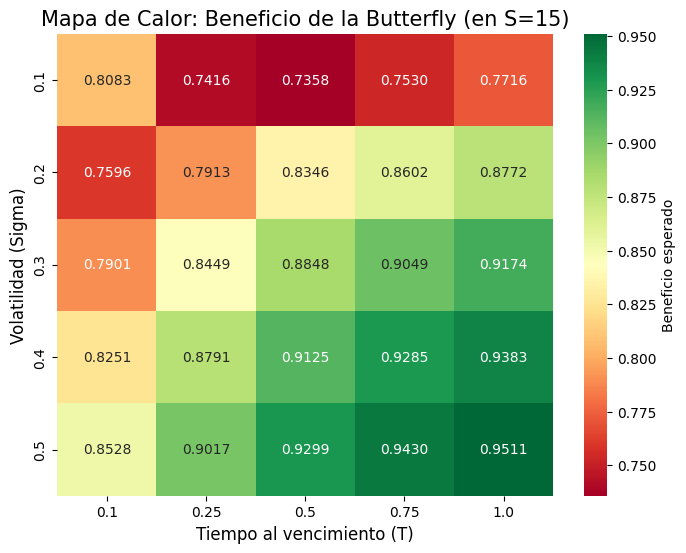

In [30]:
# Definición de rangos para el heatmap
tiempos = [0.1, 0.25, 0.5, 0.75, 1.0]
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5]
S_fijo = 15.0  # Evaluamos en el punto óptimo del "sombrero"

# Matriz para almacenar los resultados
data_heatmap = np.zeros((len(sigmas), len(tiempos)))

# Llenado de la matriz (Cálculo del P&L en S = 15)
for i, sigma in enumerate(sigmas):
    for j, t in enumerate(tiempos):
        # Valoración de opciones
        C_K, _ = calcular_black_scholes(S0, K, t, rc, sigma, dc)
        C_K_prima, _ = calcular_black_scholes(S0, K_prima, t, rc, sigma, dc)
        C_K_biprima, _ = calcular_black_scholes(S0, K_biprima, t, rc, sigma, dc)

        coste = (C_K + C_K_prima - 2 * C_K_biprima)

        # Payoff en S = 15
        payoff = (max(S_fijo - K, 0) + max(S_fijo - K_prima, 0) - 2 * max(S_fijo - K_biprima, 0))

        data_heatmap[i, j] = payoff - coste

# Creación del DataFrame para Seaborn
df_heatmap = pd.DataFrame(data_heatmap, index=sigmas, columns=tiempos)

# Generación del Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_heatmap, annot=True, cmap="RdYlGn", fmt=".4f", cbar_kws={'label': 'Beneficio esperado'})

plt.title('Mapa de Calor: Beneficio de la Butterfly (en S=15)', fontsize=15)
plt.xlabel('Tiempo al vencimiento (T)', fontsize=12)
plt.ylabel('Volatilidad (Sigma)', fontsize=12)
plt.show()

### Sensibilidad Conjunta a $T$ y $\sigma$

Este mapa de calor evalúa el beneficio neto de la estrategia en el escenario ideal: cuando el precio de la acción al vencimiento se clava exactamente en el strike central ($S=15.0$), maximizando el pago bruto a 1.00 € (como se observa en la cúspide de la gráfica de *payoff*). Al analizar cómo afectan el tiempo ($T$) y la volatilidad ($\sigma$) al coste de instalación que restamos a ese euro de ganancia, se obtienen las siguientes conclusiones:

* **El Escenario Óptimo (Máxima Rentabilidad):** El mayor beneficio neto de toda la matriz se alcanza en la esquina inferior derecha (**0.9511 €**, con $T=1.0$ y $\sigma=0.5$). Esto ocurre porque, como se demostró en los análisis individuales, la combinación de un plazo largo y una alta volatilidad desploma el coste de la mariposa a su nivel mínimo. Al ser la estructura extremadamente barata en $t=0$, el rendimiento neto obtenido si la acción termina en el centro se acerca casi por completo al euro teórico.
* **El Escenario Crítico (Mínima Rentabilidad):** Por el contrario, la zona con menores ganancias netas se concentra en la esquina superior (**0.7358 €**, con $T=0.5$ y $\sigma=0.1$). Con volatilidades muy bajas y plazos intermedios, las opciones compradas de los extremos retienen un valor relativo alto frente a las vendidas en el centro, encareciendo la estructura inicial y "recortando" el beneficio neto final en más de un 25% respecto al caso óptimo.
* **El Efecto de Diagonal Transversal (Comportamiento de Vega y Theta):** El mapa refleja visualmente que el beneficio esperado en $S=15$ crece de forma consistente al desplazarnos **hacia abajo** (mayor volatilidad) y **hacia la derecha** (mayor tiempo). Esto confirma que, desde la perspectiva del coste de adquisición, el comprador de una mariposa tiene una posición expuesta de forma positiva a incrementos de $T$ y $\sigma$ en el momento de armar la estrategia.

## Estrategia Strangle

- **(a.)** Teniendo en cuenta las consideraciones anteriores y dependiendo del resultado del subyacente define y muestra la tabla de payoffs antes de desarrollar el código.

| Escenario Subyacente | $\text{Put } K$ | $\text{Call } K'$ | Resultado de la Estrategia |
| :---: | :---: | :---: | :---: |
| $S \le K$ | $K - S$ | $0$ | $K - S$ |
| $K < S \le K'$ | $0$ | $0$ | $0$ |
| $S > K'$ | $0$ | $S - K'$ | $S - K'$ |

Apartado b) y c)

- **(b.)** Obtener mediante simulación el valor de una estrategia **strangle** formada por la compra de una opción call europea con strike $K$, la compra de otra opción europea con strike $K'>K$ y la venta de dos opciones call europeas con strike $K''$ tal que $K<K''<K'$, todas sobre el mismo subyacente.  
Aplicarlo suponiendo los datos de las prácticas anteriores con $K = 14, K' = 16$ y $K'' = 15$.

- **(c.)** Grafica el resultado y comprueba que el gráfico tiene la misma forma que lo ya visto en la parte de teoría.

La estrategia **Strangle** es una estructura de volatilidad abierta que se construye mediante la combinación de dos tramos con diferentes precios de ejercicio sobre el mismo activo subyacente, cumpliendo la relación $K < K'$. En este diseño, el inversor busca fuertes movimientos del mercado sin importar la dirección. Los parámetros de referencia son:

1. **Compra (Largo)** de 1 opción Put con precio de ejercicio en este caso particular de $K = 14$.
2. **Compra (Largo)** de 1 opción Call con precio de ejercicio igual a $K' = 16$.

A continuación, se detalla el comportamiento algebraico y el desglose del payoff resultante en cada uno de los rangos posibles en los que puede expirar el precio del subyacente ($S_T$) al vencimiento:

---

#### 1. Rango $S_T \le K$ *(Caso particular: $S_T \le 14$)*
* **Comportamiento:** El precio del activo se desploma por debajo del soporte inferior. La opción Call ($K'$) expira completamente *Out-of-the-Money* (OTM) con valor cero, pero la opción Put entra *In-the-Money* (ITM), acumulando un valor intrínseco de $(K - S_T)$.
* **Desarrollo General:** $(K - S_T) + 0$
* **Resultado Neto:** $\mathbf{14 - S_T}$ *(El beneficio de la estrategia aumenta de forma lineal a medida que el precio del subyacente experimenta caídas más profundas)*.

#### 2. Rango $K < S_T \le K'$ *(Caso particular: $14 < S_T \le 16$)*
* **Comportamiento:** El subyacente expira atrapado en el canal intermedio entre ambos strikes. Tanto la Put de base como la Call superior se encuentran *Out-of-the-Money* (OTM), por lo que ninguna opción ejerce su derecho.
* **Desarrollo General:** $0 + 0 = 0$
* **Resultado Neto:** $\mathbf{0}$ *(Zona neutra de payoff bruto donde no se rescata ningún valor intrínseco)*.

#### 3. Rango $S_T > K'$ *(Caso particular: $S_T > 16$)*
* **Comportamiento:** El precio del activo experimenta una fuerte subida alcista. En este escenario, la opción Put ($K$) pierde todo su valor y vence en cero, mientras que la opción Call entra profundamente *In-the-Money* (ITM), aportando un valor de $(S_T - K')$.
* **Desarrollo General:** $0 + (S_T - K')$
* **Resultado Neto:** $\mathbf{S_T - 16}$ *(El beneficio de la estrategia aumenta de forma lineal a medida que el precio del subyacente experimenta subidas más intensas)*.



S_T Simulado    | Payoff Strangle
---------------------------------
11.9626         | 2.0374         
12.8620         | 1.1380         
16.1857         | 0.1857         
18.8871         | 2.8871         
7.8778          | 6.1222         


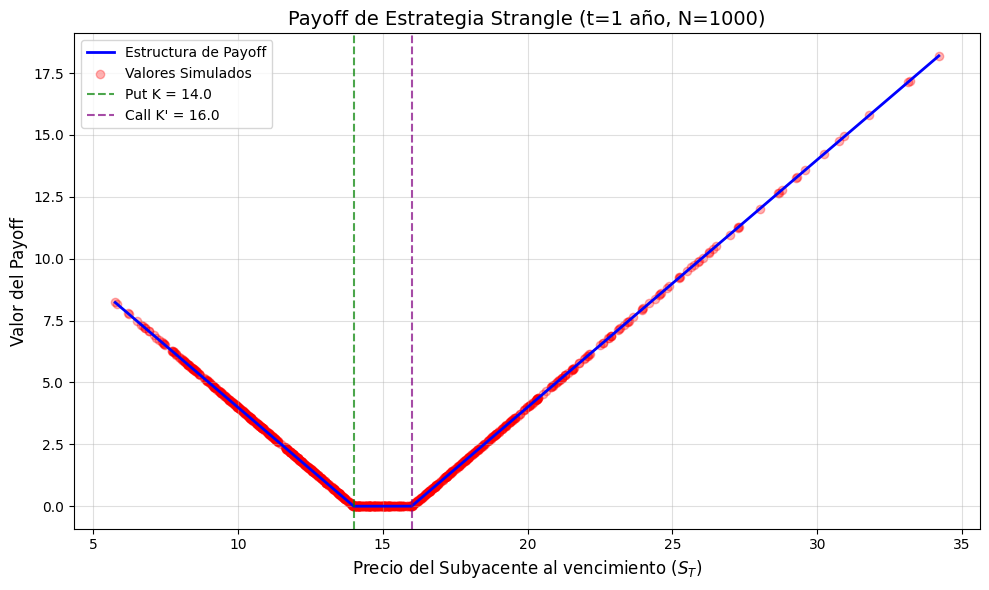

In [31]:
# Configuración de parámetros
S0 = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
t = 1
n_sim = 1000

# Strikes de la estrategia Strangle
K = 14.0       # Strike de la Put
K_prima = 16.0 # Strike de la Call

# Parámetros para el generador aleatorio
m = 2**31 - 1
a = 16807
c = 0
x0 = 123456789

# Conversión a tasa continua
rc = np.log(1 + r_discreta)

# Generación de simulaciones de S_T
z1, z2,_ = generador_box_muller_rapido(n_sim, m, a, c, x0)
Z = z2

# Evolución del subyacente
ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * Z)

# Evaluación y almacenamiento del Payoff del Strangle
put_K = np.maximum(K - ST, 0)
call_K_prima = np.maximum(ST - K_prima, 0)

# Almacenamos el payoff en un array
payoffs_strangle = put_K + call_K_prima

# Mostramos los primeros 5 valores a modo de comprobación
print(f"{'S_T Simulado':<15} | {'Payoff Strangle':<15}")
print("-" * 33)
for i in range(5):
    print(f"{ST[i]:<15.4f} | {payoffs_strangle[i]:<15.4f}")

# Gráfica de los resultados
ST_ordenado = np.sort(ST)
payoffs_teorico = np.maximum(K - ST_ordenado, 0) + np.maximum(ST_ordenado - K_prima, 0)

plt.figure(figsize=(10, 6))

# Dibujar la línea de la estructura de pagos
plt.plot(ST_ordenado, payoffs_teorico, color='blue', linewidth=2, label='Estructura de Payoff')

# Superponer los puntos simulados
plt.scatter(ST, payoffs_strangle, color='red', alpha=0.3, label='Valores Simulados')

# Marcar los strikes con líneas verticales
plt.axvline(x=K, color='green', linestyle='--', alpha=0.7, label=f"Put K = {K}")
plt.axvline(x=K_prima, color='purple', linestyle='--', alpha=0.7, label=f"Call K' = {K_prima}")

# Configuración visual
plt.title(f'Payoff de Estrategia Strangle (t={t} año, N={n_sim})', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Valor del Payoff', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

# Mostrar gráfica
plt.show()

Al observar los primeros valores generados por el simulador, se evidencia de manera práctica el comportamiento dinámico de la estrategia ante diferentes movimientos del activo:

* **Escenarios Bajistas ($S_T \le 14$):** En las trayectorias donde el subyacente sufre caídas significativas, como en los escenarios simulados de **$11.9626$** y **$7.8778$**, la opción Call vence sin valor, pero la opción Put se activa profundamente en el dinero (*In-the-Money*). Esto genera payoffs brutos de **$2.0374$** y **$6.1222$** respectivamente, demostrando de forma exacta la relación matemática $(14 - S_T)$.
* **Escenarios Alcistas ($S_T > 16$):** Por el contrario, cuando el activo experimenta un rally al alza, como en las simulaciones de **$16.1857$** y **$18.8871$**, la Put se desinfla hasta cero y la Call es la que captura todo el valor intrínseco. Así, se registran retornos de **$0.1857$** y **$2.8871$** calculados mediante la réplica lineal $(S_T - 16)$.
* **Escenarios Atrapados en el Canal ($14 < S_T \le 16$):** En el caso simulado de **$12.8620$**, el precio se encuentra por debajo del strike de la Put ($K=14$), lo que le otorga un payoff de $14 - 12.8620 = \mathbf{1.1380}$. Si alguna de las trayectorias aleatorias hubiese finalizado estrictamente en el rango central (por ejemplo, en $15.0$), el rendimiento de la tabla habría sido un cero absoluto.

---

**Conclusión del Perfil de Riesgo Abierto:** A diferencia de la mariposa, el *Strangle* no es una estrategia acotada en sus extremos, sino una estructura diseñada para capturar rupturas drásticas de precio. Al no contar con opciones vendidas que neutralicen las tendencias, los flancos laterales se mantienen completamente libres. Como validan los datos simulados, si la acción sufre una caída severa por debajo de 14 o un rally alcista por encima de 16, el resultado final crece de forma ilimitada, ofreciendo un potencial de ganancias infinito a cambio del coste de pagar ambas primas en $t=0$.

- **(d.)** Muestra graficamente cual sería el beneficio obtenido, es decir, considerando el coste de la prima.

--- Desglose de Costes (t=0) ---
Put K (14.0):      1.4490
Call K' (16.0):    1.0976
Prima Neta:       2.5466
Comisiones:       0.0127
COSTE TOTAL:      2.5593



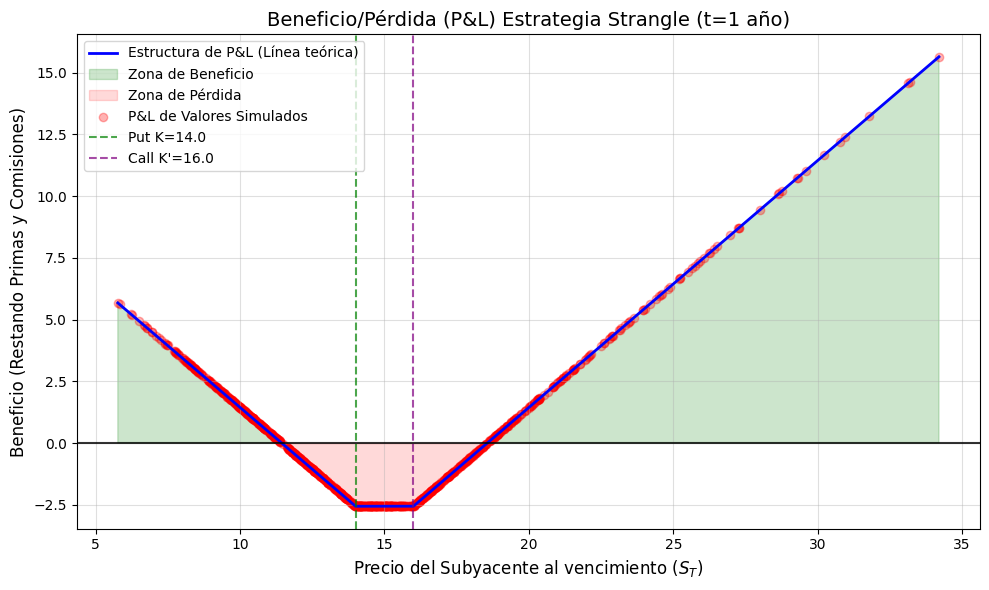

In [32]:
# Configuración de parámetros
S0 = 14.0
r_discreta = 0.03
sigma = 0.3
dc = 0.0
t = 1
n_sim = 1000

# Strikes del Strangle
K = 14.0       # Strike de la Put
K_prima = 16.0 # Strike de la Call

# Conversión a tasa continua
rc = np.log(1 + r_discreta)

# 3. Cálculo de Primas y Costes en t=0
_, P_K = calcular_black_scholes(S0, K, t, rc, sigma, dc)
C_K_prima, _ = calcular_black_scholes(S0, K_prima, t, rc, sigma, dc)

# Prima neta (ambas opciones son compradas, se suman los costes)
prima_neta = P_K + C_K_prima

# Comisiones (0.5% sobre el volumen total de primas operadas)
comisiones = 0.005 * (P_K + C_K_prima)

# Coste total de armar la estrategia
coste_total = prima_neta + comisiones

print("--- Desglose de Costes (t=0) ---")
print(f"Put K ({K}):      {P_K:.4f}")
print(f"Call K' ({K_prima}):    {C_K_prima:.4f}")
print(f"Prima Neta:       {prima_neta:.4f}")
print(f"Comisiones:       {comisiones:.4f}")
print(f"COSTE TOTAL:      {coste_total:.4f}\n")

# Generación de simulaciones
m, a, c, x0 = 2**31 - 1, 16807, 0, 123456789
_, z2, _ = generador_box_muller_rapido(n_sim, m, a, c, x0)
ST = S0 * np.exp((rc - dc - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * z2)

# Evaluación del Payoff y P&L (Beneficio/Pérdida)
put_K_sim = np.maximum(K - ST, 0)
call_K_prima_sim = np.maximum(ST - K_prima, 0)

payoffs_strangle = put_K_sim + call_K_prima_sim

# Restamos el coste total para obtener el Beneficio Real (Profit & Loss)
pnl_strangle = payoffs_strangle - coste_total

# Gráfica de P&L
ST_ordenado = np.sort(ST)
payoffs_teorico = np.maximum(K - ST_ordenado, 0) + np.maximum(ST_ordenado - K_prima, 0)
pnl_teorico = payoffs_teorico - coste_total

plt.figure(figsize=(10, 6))

# Línea teórica de Beneficio/Pérdida
plt.plot(ST_ordenado, pnl_teorico, color='blue', linewidth=2, label='Estructura de P&L (Línea teórica)')

# Sombreado verde para la zona de ganancias (valores por encima de 0)
plt.fill_between(ST_ordenado, pnl_teorico, 0, where=(pnl_teorico > 0), color='green', alpha=0.2, label='Zona de Beneficio')

# Sombreado rojo para la zona de pérdidas (valores por debajo de 0)
plt.fill_between(ST_ordenado, pnl_teorico, 0, where=(pnl_teorico < 0), color='red', alpha=0.15, label='Zona de Pérdida')
# Puntos simulados de Beneficio/Pérdida
plt.scatter(ST, pnl_strangle, color='red', alpha=0.3, label='P&L de Valores Simulados')

# Línea cero (Breakeven point general)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

# Marcar strikes
plt.axvline(x=K, color='green', linestyle='--', alpha=0.7, label=f"Put K={K}")
plt.axvline(x=K_prima, color='purple', linestyle='--', alpha=0.7, label=f"Call K'={K_prima}")

# Configuración visual
plt.title(f'Beneficio/Pérdida (P&L) Estrategia Strangle (t={t} año)', fontsize=14)
plt.xlabel('Precio del Subyacente al vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Beneficio (Restando Primas y Comisiones)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

Al incorporar el coste total de la estrategia (la suma de las primas de la Put y la Call más sus respectivas comisiones de operación), el gráfico se transforma de un perfil de ingresos brutos (*payoff*) a una estructura real de **Beneficio/Pérdida Neto (P&L)**. Del análisis de esta nueva distribución visual, podemos extraer las siguientes conclusiones:

* **El Costo del "Boleto de Entrada" como Pérdida Máxima:** A diferencia del gráfico de payoffs donde el canal central plano tocaba el cero, aquí toda la estructura se desplaza verticalmente hacia abajo en **2.5593 €**. Ese hundimiento representa el coste de asegurar ambos flancos en $t=0$. Si el activo experimenta baja volatilidad y cierra atrapado entre ambos strikes, el inversor asume su **pérdida máxima acotada** (marcada por la **zona roja** central), perdiendo la totalidad del capital invertido inicialmente.

* **Ensanchamiento del Umbral de Activación:** El sombreado verde revela visualmente la verdadera "zona de ganancias" de la estrategia. Un detalle crucial es que para entrar en beneficios, el precio del subyacente no solo debe rebasar los strikes laterales ($K=14.0$ o $K'=16.0$), sino que tiene que desplazarse lo suficiente para absorber el coste total de las primas. Esto genera dos puntos de equilibrio exactos notablemente alejados del centro: un umbral bajista en $11.4407$ € ($14.0 - 2.5593$) y un umbral alcista en $18.5593$ € ($16.0 + 2.5593$).

* **Exposición Abierta y Suelo de Riesgo Controlado:** La **zona verde** ilustra la naturaleza asimétrica del *Strangle*. A diferencia de la mariposa, aquí **no existe un techo de rendimiento**: si la acción sufre un desplome severo o un rally masivo, el potencial de ganancia neta se dispara de forma ilimitada a lo largo de las colas exteriores. La contrapartida de este perfil de volatilidad es que exige movimientos de precio drásticos para resultar rentable, ofreciendo un riesgo rígidamente acotado en el centro a cambio de una exposición abierta al éxito en las tendencias extremas.